In [2]:
import pandas as pd
from citeline.embedders import Embedder
from citeline.database.milvusdb import MilvusDB

samples = pd.read_json("../data/dataset/nontrivial_10.jsonl", lines=True)
db = MilvusDB()

print(samples.head(2))
print("===================================")
db.healthcheck()

                    source_doi  \
0    10.1007/s00159-008-0010-0   
1  10.1016/j.newar.2004.03.017   

                                       sent_original  \
0  (Shang et al. 1998), do show unusual, faint fe...   
1  Novak et al. (2003) studied the dust emission ...   

                                         sent_no_cit  sent_idx  \
0  (), do show unusual, faint features in their s...       159   
1   studied the dust emission at 450 μm in the ga...      1329   

      citation_dois   pubdate      resolved_bibcodes  \
0  [10.1086/311563]  20080601  [1998ApJ...504L..23S]   
1  [10.1086/368156]  20040901  [2003ApJ...583L..83N]   

                                     sent_cit_masked  
0  ([REF]), do show unusual, faint features in th...  
1  [REF] studied the dust emission at 450 μm in t...  
Milvus server version: 2.6.0


In [ ]:
type(samples.pubdate.iloc[0])
type(samples.pubdate.iloc[0].to_int)

numpy.int64

In [3]:
embedder = Embedder.create(
    model_name="Qwen/Qwen3-Embedding-0.6B", 
    device="mps",
    normalize=True
)

print(embedder)

Qwen/Qwen3-Embedding-0.6B, device=mps, normalize=True, dim=1024


In [ ]:
query_vectors = embedder(samples['sent_no_cit']) # (10, 1024) numpy array

In [9]:
db.list_collections()

Collections:
 - astrobert_chunks: 460801 entities
 - astrobert_contributions: 89860 entities
 - bge_chunks: 460801 entities
 - bge_contributions: 89860 entities
 - nasa_chunks: 460801 entities
 - nasa_contributions: 89860 entities
 - qwen06_chunks: 460801 entities
 - qwen06_contributions: 89860 entities
 - qwen06_findings_v2: 4342 entities
 - qwen06_v3_contributions: 299286 entities
 - qwen8b_contributions: 89860 entities
 - specter_chunks: 460801 entities
 - specter_contributions: 89860 entities


In [11]:
COLLECTION_NAME = "qwen06_chunks"
query_records = samples.to_dict(orient="records")
type(query_records)

list

In [14]:
COLLECTION_NAME = "qwen06_chunks"
query_records = samples.to_dict(orient="records")
results = db.search(
    collection_name=COLLECTION_NAME,
    query_records=query_records,
    query_vectors=query_vectors,
    limit=200
)


In [24]:
results[0][0]
def scores(result):
    return [hit["metric"] for hit in result]
similarities = [scores(result) for result in results]

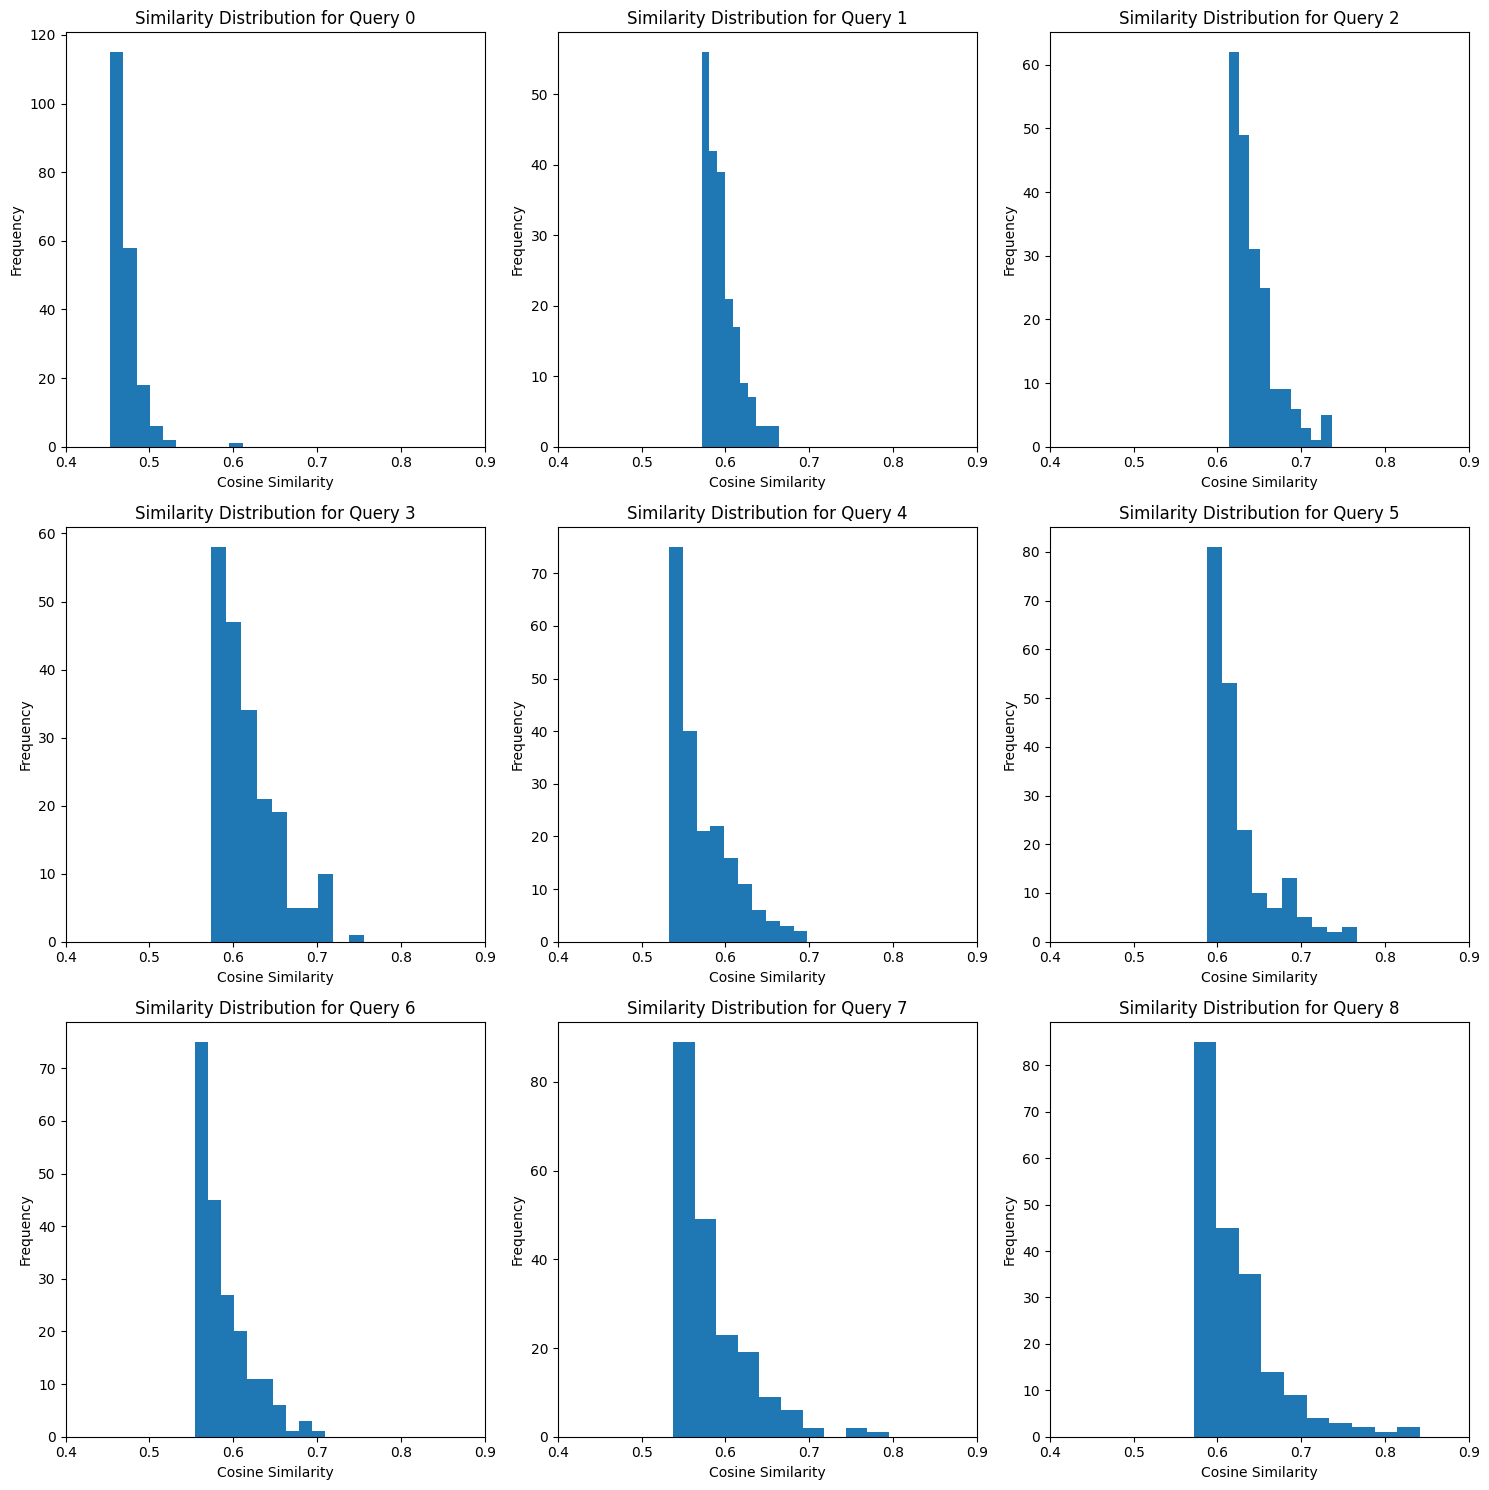

In [29]:
# Plot the first 9 similarity distributions as 3 x 3 subplots
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for i in range(9):
    ax = axes[i // 3, i % 3]
    ax.hist(similarities[i])
    ax.set_title(f"Similarity Distribution for Query {i}")
    ax.set_xlim(0.4, 0.9)
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
results = db.select_by_doi(doi="10.1086/311563", collection_name="qwen06_chunks")
vectors = np.array(results['vector'].tolist())
print(vectors.shape)

(15, 1024)
